In [1]:
import matplotlib.pyplot as plt
import dask.array as da
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd
import os
import numpy as np
from scipy import ndimage as ndi

In [3]:
# read in image
root = "/yoren62/users/hannahbolen/immunofluorescence/slidescan_20250723_o8_gH2AX/o8_vsi/converted/"
img_name = "o8p_day3_s12.ome.tif"
img_path = os.path.join(root, img_name)
img = tifffile.imread(img_path, aszarr=True)
img = da.from_zarr(img)
nuclei = img[0]
cy5 = img[1]

In [4]:
# constants
gfp_intensity = (256, 6000)
cy5_intensity = (256, 6000)
ds = 10

# create downsampled images
nuclei_ds = nuclei[::ds,::ds]
cy5_ds = cy5[::ds,::ds]

# constants for tile
H, W = nuclei.shape
l = 512*10
y0 = H//2 - l//2
x0 = W//2 - l//2

# make tiles
nucleiTile = nuclei[y0:y0+l, x0:x0+l]
cy5Tile = cy5[y0:y0+l, x0:x0+l]
# make downsampled tiles
nucleiTile_ds = nucleiTile[::ds,::ds]
cy5Tile_ds = cy5Tile[::ds,::ds]

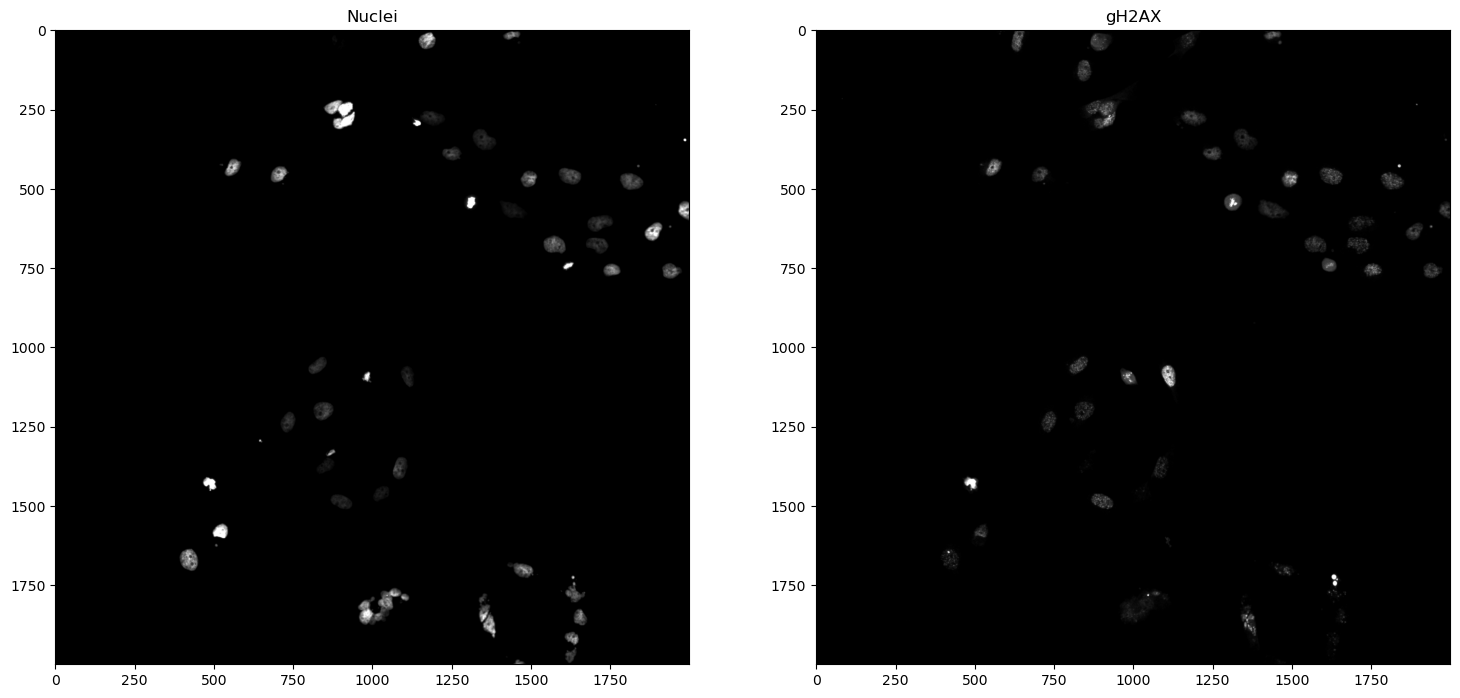

In [7]:
fullRes = True
zoom = True
# plot downsampled tiles
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if fullRes:
    if zoom:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile[1000:3000, 2000:4000], in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile[1000:3000, 2000:4000], in_range = cy5_intensity), cmap="gray")
    else:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile, in_range = cy5_intensity), cmap="gray")
else:
    if zoom:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile_ds[1000:3000, 2000:4000], in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile_ds[1000:3000, 2000:4000], in_range = cy5_intensity), cmap="gray")
    else:
        ax[0].imshow(ski.exposure.rescale_intensity(nucleiTile_ds, in_range = gfp_intensity), cmap = "gray")
        ax[1].imshow(ski.exposure.rescale_intensity(cy5Tile_ds, in_range = cy5_intensity), cmap="gray")
ax[0].set_title("Nuclei")
ax[1].set_title("gH2AX")
plt.show()

In [18]:
radius = 150
neighborhood = ski.morphology.disk(radius)
min_threshold = 100
preprocess_nucleiTile = ski.util.img_as_ubyte(ski.filters.gaussian(ski.exposure.rescale_intensity(nucleiTile, in_range = gfp_intensity), sigma = 1.3))
local_otsu = np.maximum(ski.filters.rank.otsu(preprocess_nucleiTile, neighborhood), min_threshold)
binary_tile = ndi.binary_fill_holes(preprocess_nucleiTile >= local_otsu)
masked_nucleiTile = nucleiTile*binary_tile

In [20]:
new_threshold = 20
binary_new = ndi.binary_fill_holes(preprocess_nucleiTile >= new_threshold)
masked_newTile = nucleiTile*binary_new

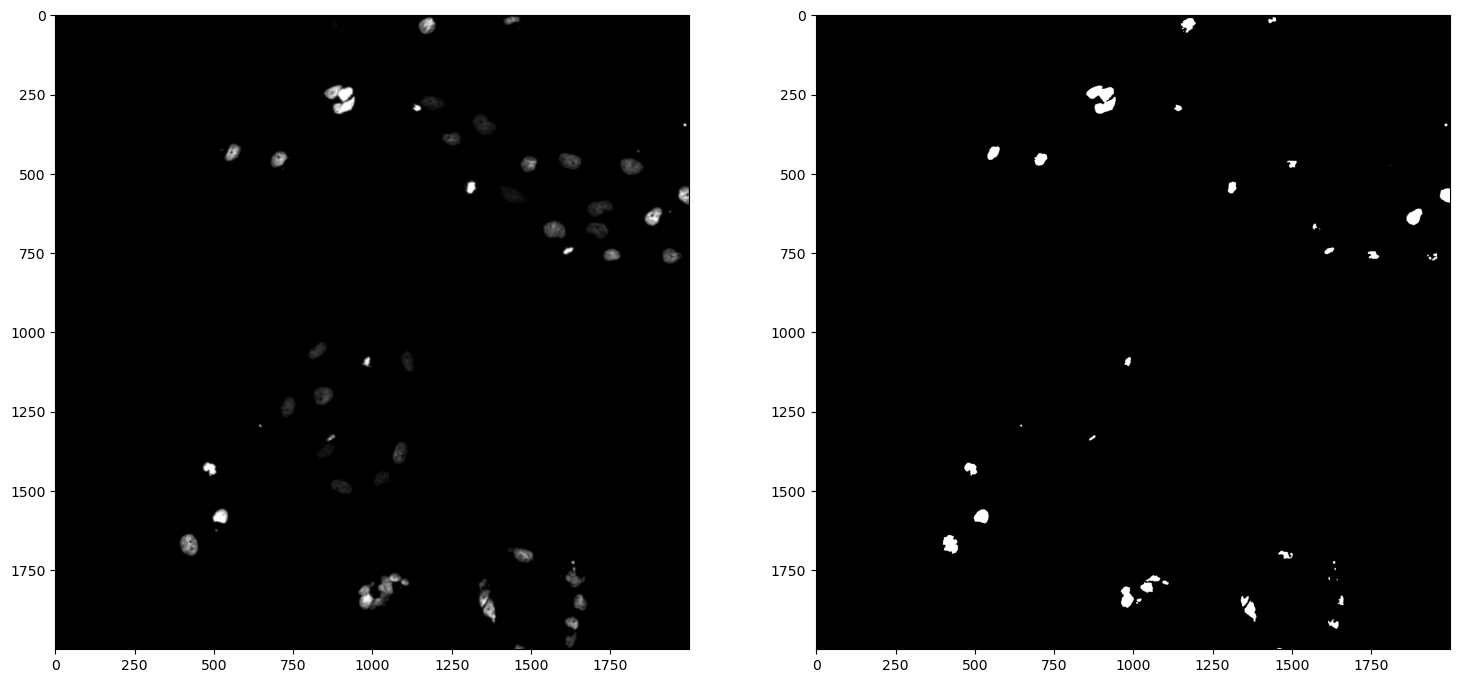

In [19]:
# plot mask and full resolution nuclei tile, assess local otsu thresholding
zoom = True
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if zoom:
    ax[0].imshow(preprocess_nucleiTile[1000:3000, 2000:4000], cmap = "gray")
    ax[1].imshow(binary_tile[1000:3000, 2000:4000], cmap="gray")
else:
    ax[0].imshow(preprocess_nucleiTile, cmap = "gray")
    ax[1].imshow(binary_tile, cmap="gray")
plt.show()

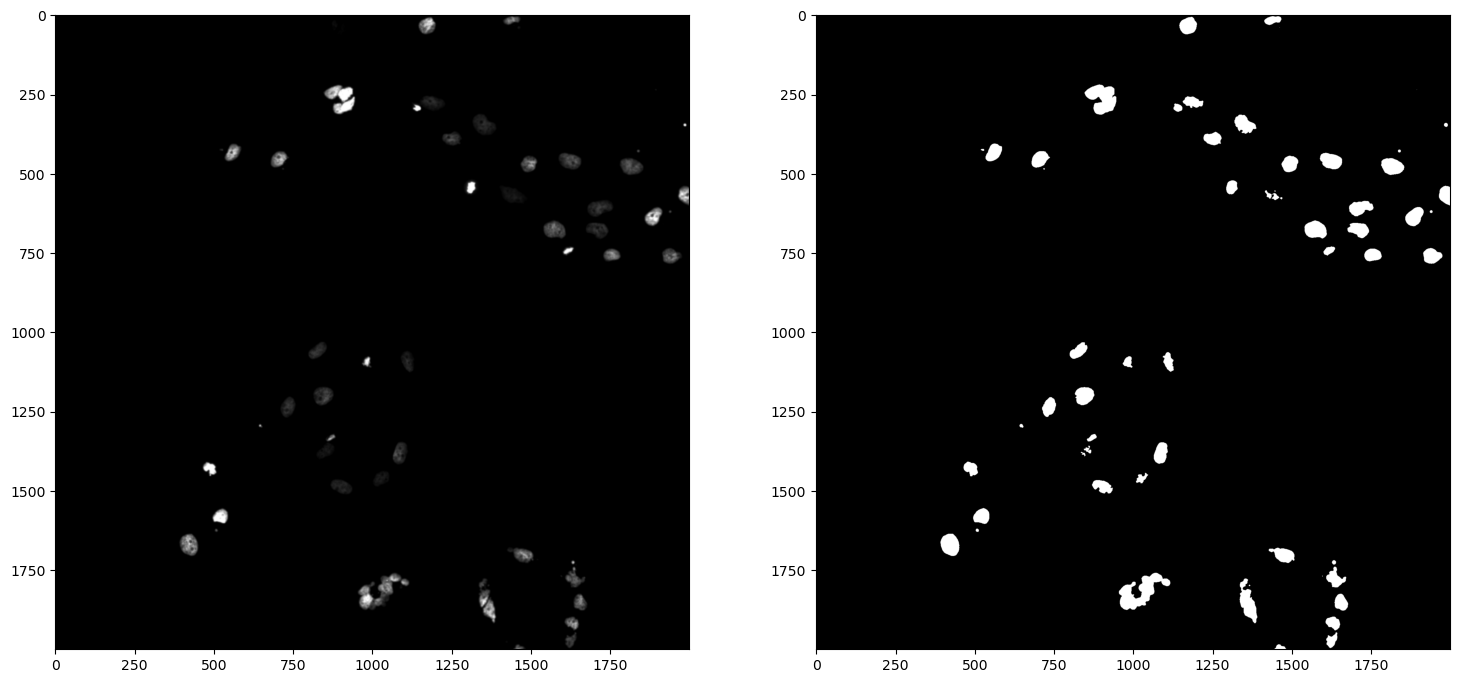

In [22]:
# plot mask and full resolution nuclei tile, assess local otsu thresholding
zoom = True
fig, ax = plt.subplots(ncols = 2, figsize = (18, 18))
if zoom:
    ax[0].imshow(preprocess_nucleiTile[1000:3000, 2000:4000], cmap = "gray")
    ax[1].imshow(binary_new[1000:3000, 2000:4000], cmap="gray")
else:
    ax[0].imshow(preprocess_nucleiTile, cmap = "gray")
    ax[1].imshow(binary_new, cmap="gray")
plt.show()